In [ ]:
#NAME:THEEBAK S

In [ ]:
#DATASET A (NYPD CRIME DATASET)

Experiment Configuration: {'dataset': 'NYPD Complaint Data Historic', 'date_col': 'CMPLNT_FR_DT', 'location_col': 'BORO_NM', 'location_value': 'BROOKLYN', 'frequency': 'W-MON', 'test_periods': 12, 'seed': 42}

--- Summary Statistics of Target Series ---
count     314.000000
mean     2676.579618
std       280.629612
min       198.000000
25%      2527.250000
50%      2687.000000
75%      2853.500000
max      3258.000000
Name: incidents, dtype: float64

Training set: 2014-01-06 to 2019-10-14 (302 steps)
Locked Test set: 2019-10-21 to 2020-01-06 (12 steps)

--- Stationarity Test (Training Only) ---
ADF Statistic: -5.0416 | p-value: 1.8345e-05


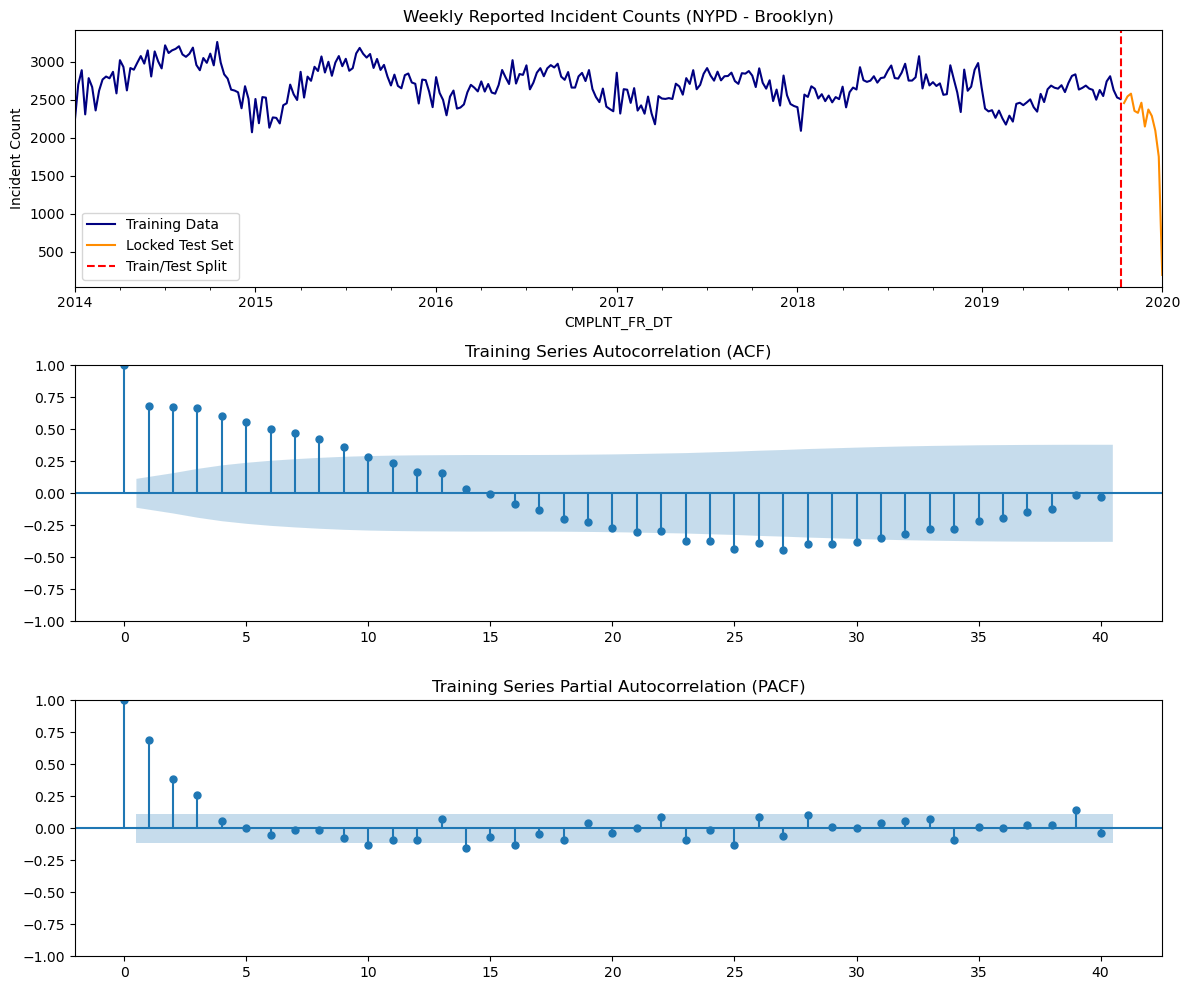


Naive Benchmark: MAE = 395.25, RMSE = 727.27
AR(4):       MAE = 472.76, RMSE = 792.32

Training-Selected ARIMA Order: (2, 1, 1) (AIC: 3890.42)
ARIMA(2, 1, 1):   MAE = 428.40, RMSE = 751.48

--- ARIMA Residual Ljung-Box Test ---
      lb_stat  lb_pvalue
10  14.511854   0.150898
20  25.165629   0.195168

--- Final Model Evaluation Table ---
         Model Order/Lags   Train AIC        MAE       RMSE  Ljung-Box p(10)
Naive Baseline          -         NaN 395.250000 727.265369              NaN
ARIMA(2, 1, 1)  (2, 1, 1) 3890.419875 428.404179 751.480262         0.150898
         AR(4)        p=4 3828.138378 472.755339 792.323286              NaN


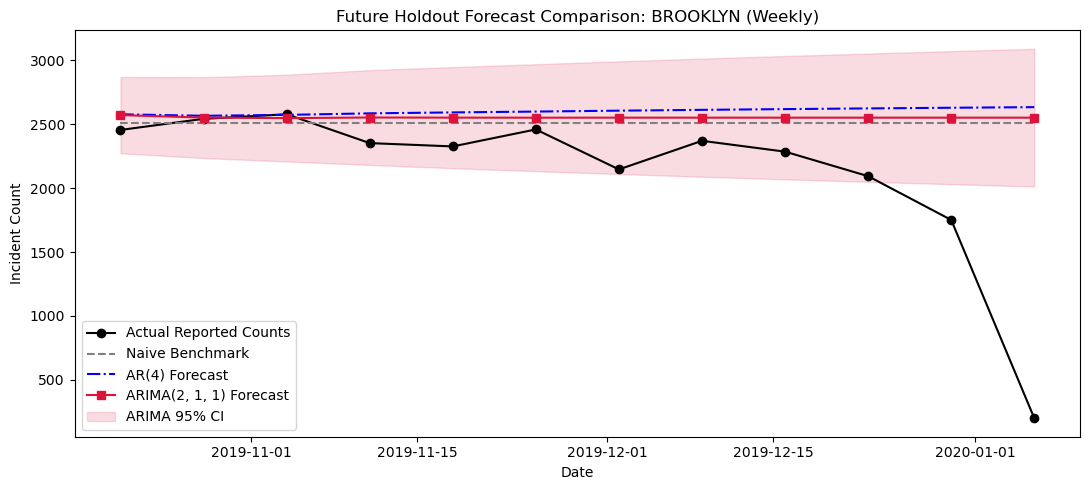


Pipeline execution complete. All artifacts and figures saved to /lab06_outputs.


In [2]:
import os
import glob
import json
import platform
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox

# ==========================================
# 0. CONFIGURATION & EXPERIMENT SETUP
# ==========================================
SEED = 42
np.random.seed(SEED)

OUT = Path("lab06_outputs")
OUT.mkdir(exist_ok=True)

CONFIG = {
    "dataset": "NYPD Complaint Data Historic",
    "date_col": "CMPLNT_FR_DT",
    "location_col": "BORO_NM",
    "location_value": "BROOKLYN", 
    "frequency": "W-MON",         
    "test_periods": 12,           
    "seed": SEED
}
print("Experiment Configuration:", CONFIG)

# ==========================================
# 1. DATA LOADING & AUDIT
# ==========================================
# ==========================================
# 1. DATA LOADING & AUDIT
# ==========================================

DATA_PATH = r"C:\Users\ADMIN\Downloads\NYPD_Complaint_Data_Historic.csv\NYPD_Complaint_Data_Historic.csv"

# Verify file exists
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f"File not found at: {DATA_PATH}")

# Load only the required columns for time series aggregation
use_cols = [CONFIG["date_col"], CONFIG["location_col"], "LAW_CAT_CD"]

df = pd.read_csv(
    DATA_PATH,
    usecols=use_cols,
    low_memory=False
)

# Parse occurrence dates and filter valid ranges
df[CONFIG["date_col"]] = pd.to_datetime(df[CONFIG["date_col"]], errors="coerce")
df = df.dropna(subset=[CONFIG["date_col"], CONFIG["location_col"]]).copy()

# Focus on a representative multi-year window (e.g., 2014 to 2019) to avoid historic data entry gaps
df = df[(df[CONFIG["date_col"]] >= "2014-01-01") & (df[CONFIG["date_col"]] <= "2019-12-31")]

# ==========================================
# 2. TIME SERIES AGGREGATION (Location-Specific)
# ==========================================
loc_df = df[df[CONFIG["location_col"]].astype(str).str.upper() == CONFIG["location_value"]].copy()
assert len(loc_df) > 0, f"No records found for location: {CONFIG['location_value']}"

# Aggregate to regular weekly complaint counts
y = (loc_df.set_index(CONFIG["date_col"])
     .resample(CONFIG["frequency"])
     .size()
     .rename("incidents")
     .asfreq(CONFIG["frequency"], fill_value=0))

# Acceptance integrity checks
assert y.index.is_monotonic_increasing
assert y.index.is_unique
assert y.isna().sum() == 0

print("\n--- Summary Statistics of Target Series ---")
print(y.describe())

# ==========================================
# 3. LEAKAGE-SAFE CHRONOLOGICAL SPLIT
# ==========================================
H = CONFIG["test_periods"]
assert len(y) > 3 * H, "Series is too short for the chosen holdout period."

# Chronological split: oldest data for train, newest H weeks for test
train, test = y.iloc[:-H], y.iloc[-H:]

assert train.index.max() < test.index.min()
assert len(test) == H
print(f"\nTraining set: {train.index.min().date()} to {train.index.max().date()} ({len(train)} steps)")
print(f"Locked Test set: {test.index.min().date()} to {test.index.max().date()} ({len(test)} steps)")

def compute_metrics(y_true, y_pred):
    return {
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "RMSE": float(mean_squared_error(y_true, y_pred) ** 0.5)
    }

# ==========================================
# 4. EXPLORATORY DATA ANALYSIS & STATIONARITY (Training Only)
# ==========================================
fig, ax = plt.subplots(3, 1, figsize=(12, 10))

# 4.1 Incident count plot with holdout boundary
train.plot(ax=ax[0], label="Training Data", color="navy")
test.plot(ax=ax[0], label="Locked Test Set", color="darkorange")
ax[0].axvline(train.index.max(), color="red", linestyle="--", label="Train/Test Split")
ax[0].set_title("Weekly Reported Incident Counts (NYPD - Brooklyn)")
ax[0].set_ylabel("Incident Count")
ax[0].legend()

# 4.2 Augmented Dickey-Fuller Test on training series
adf_stat, adf_p, _, _, crit_vals, _ = adfuller(train)
print(f"\n--- Stationarity Test (Training Only) ---")
print(f"ADF Statistic: {adf_stat:.4f} | p-value: {adf_p:.4e}")

# 4.3 ACF & PACF on training series
max_lags = min(40, len(train) // 4)
plot_acf(train, lags=max_lags, ax=ax[1], title="Training Series Autocorrelation (ACF)")
plot_pacf(train, lags=max_lags, ax=ax[2], method="ywm", title="Training Series Partial Autocorrelation (PACF)")
plt.tight_layout()
plt.savefig(OUT / "eda_and_diagnostics.png", dpi=300)
plt.show()

# ==========================================
# 5. MODEL 1: NAIVE BASELINE (Last Value)
# ==========================================
# Persistence benchmark using last observed training point
naive_pred = np.repeat(train.iloc[-1], len(test))
naive_metrics = compute_metrics(test, naive_pred)
print(f"\nNaive Benchmark: MAE = {naive_metrics['MAE']:.2f}, RMSE = {naive_metrics['RMSE']:.2f}")

# ==========================================
# 6. MODEL 2: AUTOREGRESSIVE (AR) MODEL
# ==========================================
# Selected AR order based on PACF cutoff
AR_LAGS = 4
ar_fitted = AutoReg(train, lags=AR_LAGS, trend="c", old_names=False).fit()
ar_pred = ar_fitted.predict(start=len(train), end=len(train) + len(test) - 1, dynamic=False)
ar_metrics = compute_metrics(test, ar_pred)
print(f"AR({AR_LAGS}):       MAE = {ar_metrics['MAE']:.2f}, RMSE = {ar_metrics['RMSE']:.2f}")

# ==========================================
# 7. MODEL 3: ARIMA MODEL SELECTION & FORECAST
# ==========================================
# Candidate orders chosen from training diagnostics (p, d, q)
candidates = [(1, 0, 0), (2, 0, 0), (1, 1, 1), (2, 1, 1), (4, 1, 1)]
candidate_results = []

for order in candidates:
    try:
        m = ARIMA(train, order=order).fit()
        candidate_results.append({
            "order": order,
            "AIC": m.aic,
            "BIC": m.bic,
            "fitted_model": m
        })
    except Exception as e:
        print(f"Candidate {order} failed to converge: {e}")

# Select best model strictly using training-set AIC
candidate_results.sort(key=lambda x: x["AIC"])
best_arima_info = candidate_results[0]
best_order = best_arima_info["order"]
arima_fitted = best_arima_info["fitted_model"]

print(f"\nTraining-Selected ARIMA Order: {best_order} (AIC: {best_arima_info['AIC']:.2f})")

# Forecast locked test period
arima_forecast_obj = arima_fitted.get_forecast(steps=len(test))
arima_pred = arima_forecast_obj.predicted_mean
arima_conf_int = arima_forecast_obj.conf_int(alpha=0.05)
arima_metrics = compute_metrics(test, arima_pred)
print(f"ARIMA{best_order}:   MAE = {arima_metrics['MAE']:.2f}, RMSE = {arima_metrics['RMSE']:.2f}")

# ==========================================
# 8. RESIDUAL DIAGNOSTICS
# ==========================================
resid = arima_fitted.resid.dropna()
lb_test = acorr_ljungbox(resid, lags=[10, 20], return_df=True)
print("\n--- ARIMA Residual Ljung-Box Test ---")
print(lb_test)

# ==========================================
# 9. COMPARISON TABLE & EXPORT ARTIFACTS
# ==========================================
results_df = pd.DataFrame([
    {"Model": "Naive Baseline", "Order/Lags": "-", "Train AIC": np.nan, **naive_metrics, "Ljung-Box p(10)": np.nan},
    {"Model": f"AR({AR_LAGS})", "Order/Lags": f"p={AR_LAGS}", "Train AIC": ar_fitted.aic, **ar_metrics, "Ljung-Box p(10)": np.nan},
    {"Model": f"ARIMA{best_order}", "Order/Lags": str(best_order), "Train AIC": best_arima_info["AIC"], **arima_metrics, "Ljung-Box p(10)": lb_test.loc[10, "lb_pvalue"]}
]).sort_values("MAE")

print("\n--- Final Model Evaluation Table ---")
print(results_df.to_string(index=False))

# Export comparison CSV
results_df.to_csv(OUT / "model_comparison.csv", index=False)

# Export test predictions DataFrame
pred_df = pd.DataFrame({
    "actual": test,
    "naive": naive_pred,
    "AR": np.asarray(ar_pred),
    "ARIMA": np.asarray(arima_pred),
    "ARIMA_lower_95": arima_conf_int.iloc[:, 0].values,
    "ARIMA_upper_95": arima_conf_int.iloc[:, 1].values
}, index=test.index)
pred_df.to_csv(OUT / "test_predictions.csv")

# Save manifest metadata
manifest = {
    **CONFIG,
    "n_total_periods": int(len(y)),
    "n_train": int(len(train)),
    "n_test": int(len(test)),
    "selected_arima_order": list(best_order),
    "python_version": sys.version,
    "platform": platform.platform()
}
(OUT / "manifest.json").write_text(json.dumps(manifest, indent=2, default=str))

# Plot forecast comparison
plt.figure(figsize=(11, 5))
plt.plot(test.index, test, marker="o", label="Actual Reported Counts", color="black", linewidth=1.5)
plt.plot(test.index, naive_pred, linestyle="--", label="Naive Benchmark", color="gray")
plt.plot(test.index, ar_pred, linestyle="-.", label=f"AR({AR_LAGS}) Forecast", color="blue")
plt.plot(test.index, arima_pred, marker="s", label=f"ARIMA{best_order} Forecast", color="crimson")
plt.fill_between(test.index, arima_conf_int.iloc[:, 0], arima_conf_int.iloc[:, 1], color="crimson", alpha=0.15, label="ARIMA 95% CI")
plt.title(f"Future Holdout Forecast Comparison: {CONFIG['location_value']} (Weekly)")
plt.xlabel("Date")
plt.ylabel("Incident Count")
plt.legend()
plt.tight_layout()
plt.savefig(OUT / "holdout_forecast_plot.png", dpi=300)
plt.show()

# Verification acceptance assertions
assert (OUT / "model_comparison.csv").exists()
assert (OUT / "test_predictions.csv").exists()
assert (OUT / "manifest.json").exists()
print("\nPipeline execution complete. All artifacts and figures saved to /lab06_outputs.")

In [ ]:
#DATASET B (CHICAGO CRIME DATASET)

Experiment Configuration: {'dataset': 'Chicago Crimes (2001 to Present)', 'date_col': 'Date', 'location_col': 'District', 'location_value': 1, 'frequency': 'W-MON', 'test_periods': 12, 'seed': 42}

--- Summary Statistics of Target Series ---
count    314.000000
mean     266.671975
std       54.913560
min        1.000000
25%      235.000000
50%      268.000000
75%      294.750000
max      622.000000
Name: incidents, dtype: float64

Training set: 2014-01-06 to 2019-10-14 (302 weeks)
Locked Test set: 2019-10-21 to 2020-01-06 (12 weeks)

--- Stationarity Test (Training Only) ---
ADF Statistic: -2.5587 | p-value: 1.0184e-01


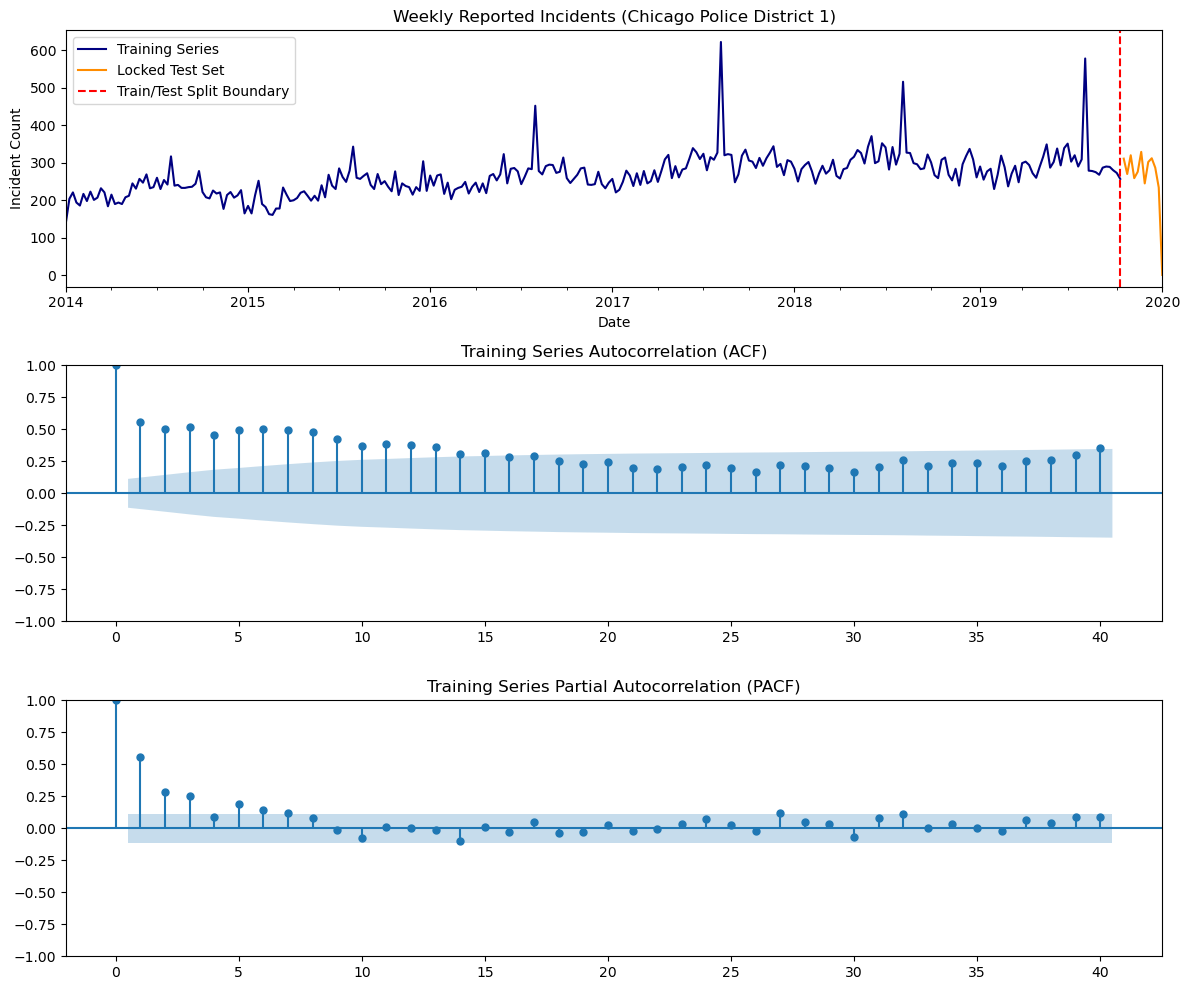


Naive Baseline: MAE = 53.67, RMSE = 84.04
AR(4):         MAE = 49.29, RMSE = 84.23

Selected ARIMA Order: (4, 1, 1) (Training AIC: 3078.45)
ARIMA(4, 1, 1):     MAE = 48.25, RMSE = 85.48

--- ARIMA Residual Ljung-Box Test ---
     lb_stat  lb_pvalue
10  4.259359   0.934889
20  9.102042   0.981695

--- Final Model Evaluation Table ---
         Model Order/Lags   Train AIC       MAE      RMSE  Ljung-Box p(10)
ARIMA(4, 1, 1)  (4, 1, 1) 3078.450802 48.254999 85.479989         0.934889
         AR(4)        p=4 3064.739559 49.291750 84.228777              NaN
Naive Baseline          -         NaN 53.666667 84.044631              NaN


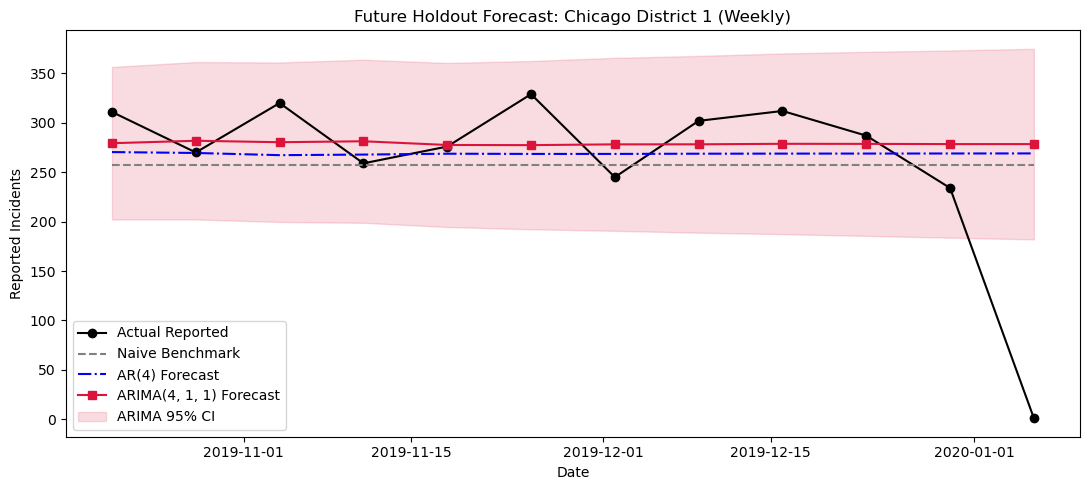


Pipeline execution complete. All artifacts saved to /lab06_outputs.


In [4]:
import os
import glob
import json
import platform
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox

# ==========================================
# 0. CONFIGURATION & REPRODUCIBILITY SETUP
# ==========================================
SEED = 42
np.random.seed(SEED)

OUT = Path("lab06_outputs")
OUT.mkdir(exist_ok=True)

CONFIG = {
    "dataset": "Chicago Crimes (2001 to Present)",
    "date_col": "Date",
    "location_col": "District",
    "location_value": 1,          # Chicago Police District 1 (Central)
    "frequency": "W-MON",         # Weekly aggregation on Mondays
    "test_periods": 12,           # 12-week chronological holdout
    "seed": SEED
}
print("Experiment Configuration:", CONFIG)

# ==========================================
# 1. DATA LOADING & FILTERING
# ==========================================

# Directly set your local file path as a raw string
DATA_PATH = r"C:\Users\ADMIN\Downloads\archive (19)\Crimes_-_2001_to_Present.csv"

# Check if the file exists
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f"File not found at: {DATA_PATH}")

# Load only the required columns
use_cols = [CONFIG["date_col"], CONFIG["location_col"], "Primary Type"]

df = pd.read_csv(
    DATA_PATH,
    usecols=use_cols,
    low_memory=False
)
# Parse occurrence timestamps
df[CONFIG["date_col"]] = pd.to_datetime(df[CONFIG["date_col"]], format="%m/%d/%Y %I:%M:%S %p", errors="coerce")
df = df.dropna(subset=[CONFIG["date_col"], CONFIG["location_col"]]).copy()

# Focus on a representative multi-year window (e.g., 2014 to 2019)
df = df[(df[CONFIG["date_col"]] >= "2014-01-01") & (df[CONFIG["date_col"]] <= "2019-12-31")]

# ==========================================
# 2. TIME SERIES CONSTRUCTION (Location-Specific)
# ==========================================
# Filter to selected police district
loc_df = df[df[CONFIG["location_col"]].astype(str).str.split('.').str[0] == str(CONFIG["location_value"])].copy()
assert len(loc_df) > 0, f"No records found for District: {CONFIG['location_value']}"

# Aggregate to regular weekly complaint counts
y = (loc_df.set_index(CONFIG["date_col"])
     .resample(CONFIG["frequency"])
     .size()
     .rename("incidents")
     .asfreq(CONFIG["frequency"], fill_value=0))

# Acceptance integrity checks
assert y.index.is_monotonic_increasing
assert y.index.is_unique
assert y.isna().sum() == 0

print("\n--- Summary Statistics of Target Series ---")
print(y.describe())

# ==========================================
# 3. LEAKAGE-SAFE CHRONOLOGICAL SPLIT
# ==========================================
H = CONFIG["test_periods"]
assert len(y) > 3 * H, "Series is too short for the chosen holdout period."

# Chronological split: oldest observations for training, newest H weeks for test
train, test = y.iloc[:-H], y.iloc[-H:]

assert train.index.max() < test.index.min()
assert len(test) == H
print(f"\nTraining set: {train.index.min().date()} to {train.index.max().date()} ({len(train)} weeks)")
print(f"Locked Test set: {test.index.min().date()} to {test.index.max().date()} ({len(test)} weeks)")

def compute_metrics(y_true, y_pred):
    return {
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "RMSE": float(mean_squared_error(y_true, y_pred) ** 0.5)
    }

# ==========================================
# 4. EXPLORATORY DATA ANALYSIS & STATIONARITY (Training Only)
# ==========================================
fig, ax = plt.subplots(3, 1, figsize=(12, 10))

# 4.1 Incident count plot with train/test boundary
train.plot(ax=ax[0], label="Training Series", color="navy")
test.plot(ax=ax[0], label="Locked Test Set", color="darkorange")
ax[0].axvline(train.index.max(), color="red", linestyle="--", label="Train/Test Split Boundary")
ax[0].set_title(f"Weekly Reported Incidents (Chicago Police District {CONFIG['location_value']})")
ax[0].set_ylabel("Incident Count")
ax[0].legend()

# 4.2 Augmented Dickey-Fuller Test on training series
adf_stat, adf_p, _, _, crit_vals, _ = adfuller(train)
print(f"\n--- Stationarity Test (Training Only) ---")
print(f"ADF Statistic: {adf_stat:.4f} | p-value: {adf_p:.4e}")

# 4.3 ACF & PACF on training series
max_lags = min(40, len(train) // 4)
plot_acf(train, lags=max_lags, ax=ax[1], title="Training Series Autocorrelation (ACF)")
plot_pacf(train, lags=max_lags, ax=ax[2], method="ywm", title="Training Series Partial Autocorrelation (PACF)")
plt.tight_layout()
plt.savefig(OUT / "eda_and_diagnostics.png", dpi=300)
plt.show()

# ==========================================
# 5. MODEL 1: NAIVE BASELINE (Last Value)
# ==========================================
# Reference benchmark using the last observed training point
naive_pred = np.repeat(train.iloc[-1], len(test))
naive_metrics = compute_metrics(test, naive_pred)
print(f"\nNaive Baseline: MAE = {naive_metrics['MAE']:.2f}, RMSE = {naive_metrics['RMSE']:.2f}")

# ==========================================
# 6. MODEL 2: AUTOREGRESSIVE (AR) MODEL
# ==========================================
# AR lag order selected based on PACF structure
AR_LAGS = 4
ar_fitted = AutoReg(train, lags=AR_LAGS, trend="c", old_names=False).fit()
ar_pred = ar_fitted.predict(start=len(train), end=len(train) + len(test) - 1, dynamic=False)
ar_metrics = compute_metrics(test, ar_pred)
print(f"AR({AR_LAGS}):         MAE = {ar_metrics['MAE']:.2f}, RMSE = {ar_metrics['RMSE']:.2f}")

# ==========================================
# 7. MODEL 3: ARIMA MODEL SELECTION & FORECAST
# ==========================================
# Candidate orders evaluated strictly on training data
candidates = [(1, 0, 0), (2, 0, 0), (1, 1, 1), (2, 1, 1), (4, 1, 1)]
candidate_results = []

for order in candidates:
    try:
        m = ARIMA(train, order=order).fit()
        candidate_results.append({
            "order": order,
            "AIC": m.aic,
            "BIC": m.bic,
            "fitted_model": m
        })
    except Exception as e:
        print(f"Candidate {order} failed: {e}")

# Select best candidate by training AIC
candidate_results.sort(key=lambda x: x["AIC"])
best_arima_info = candidate_results[0]
best_order = best_arima_info["order"]
arima_fitted = best_arima_info["fitted_model"]

print(f"\nSelected ARIMA Order: {best_order} (Training AIC: {best_arima_info['AIC']:.2f})")

# Forecast locked test horizon
arima_forecast_obj = arima_fitted.get_forecast(steps=len(test))
arima_pred = arima_forecast_obj.predicted_mean
arima_conf_int = arima_forecast_obj.conf_int(alpha=0.05)
arima_metrics = compute_metrics(test, arima_pred)
print(f"ARIMA{best_order}:     MAE = {arima_metrics['MAE']:.2f}, RMSE = {arima_metrics['RMSE']:.2f}")

# ==========================================
# 8. RESIDUAL DIAGNOSTICS
# ==========================================
resid = arima_fitted.resid.dropna()
lb_test = acorr_ljungbox(resid, lags=[10, 20], return_df=True)
print("\n--- ARIMA Residual Ljung-Box Test ---")
print(lb_test)

# ==========================================
# 9. COMPARISON TABLE & ARTIFACT EXPORT
# ==========================================
results_df = pd.DataFrame([
    {"Model": "Naive Baseline", "Order/Lags": "-", "Train AIC": np.nan, **naive_metrics, "Ljung-Box p(10)": np.nan},
    {"Model": f"AR({AR_LAGS})", "Order/Lags": f"p={AR_LAGS}", "Train AIC": ar_fitted.aic, **ar_metrics, "Ljung-Box p(10)": np.nan},
    {"Model": f"ARIMA{best_order}", "Order/Lags": str(best_order), "Train AIC": best_arima_info["AIC"], **arima_metrics, "Ljung-Box p(10)": lb_test.loc[10, "lb_pvalue"]}
]).sort_values("MAE")

print("\n--- Final Model Evaluation Table ---")
print(results_df.to_string(index=False))

# Export results
results_df.to_csv(OUT / "model_comparison.csv", index=False)

# Export predictions
pred_df = pd.DataFrame({
    "actual": test,
    "naive": naive_pred,
    "AR": np.asarray(ar_pred),
    "ARIMA": np.asarray(arima_pred),
    "ARIMA_lower_95": arima_conf_int.iloc[:, 0].values,
    "ARIMA_upper_95": arima_conf_int.iloc[:, 1].values
}, index=test.index)
pred_df.to_csv(OUT / "test_predictions.csv")

# Export manifest
manifest = {
    **CONFIG,
    "n_total_periods": int(len(y)),
    "n_train": int(len(train)),
    "n_test": int(len(test)),
    "selected_arima_order": list(best_order),
    "python_version": sys.version,
    "platform": platform.platform()
}
(OUT / "manifest.json").write_text(json.dumps(manifest, indent=2, default=str))

# Plot forecast comparison
plt.figure(figsize=(11, 5))
plt.plot(test.index, test, marker="o", label="Actual Reported", color="black", linewidth=1.5)
plt.plot(test.index, naive_pred, linestyle="--", label="Naive Benchmark", color="gray")
plt.plot(test.index, ar_pred, linestyle="-.", label=f"AR({AR_LAGS}) Forecast", color="blue")
plt.plot(test.index, arima_pred, marker="s", label=f"ARIMA{best_order} Forecast", color="crimson")
plt.fill_between(test.index, arima_conf_int.iloc[:, 0], arima_conf_int.iloc[:, 1], color="crimson", alpha=0.15, label="ARIMA 95% CI")
plt.title(f"Future Holdout Forecast: Chicago District {CONFIG['location_value']} (Weekly)")
plt.xlabel("Date")
plt.ylabel("Reported Incidents")
plt.legend()
plt.tight_layout()
plt.savefig(OUT / "holdout_forecast_plot.png", dpi=300)
plt.show()

# Verification assertions
assert (OUT / "model_comparison.csv").exists()
assert (OUT / "test_predictions.csv").exists()
assert (OUT / "manifest.json").exists()
print("\nPipeline execution complete. All artifacts saved to /lab06_outputs.")

In [ ]:
#DATASET C SAN FRANCISCO CRIME DATA

Experiment Configuration: {'dataset': 'SFPD Incident Reports: 2018 to Present', 'date_col': 'Incident Date', 'location_col': 'Police District', 'location_value': 'Mission', 'frequency': 'W-MON', 'test_periods': 12, 'seed': 42}

--- Summary Statistics of Target Series ---
count    309.000000
mean     319.692557
std       62.819102
min       59.000000
25%      275.000000
50%      310.000000
75%      368.000000
max      480.000000
Name: incidents, dtype: float64

Training set: 2018-01-01 to 2023-09-04 (297 weeks)
Locked Test set: 2023-09-11 to 2023-11-27 (12 weeks)

--- Stationarity Test (Training Only) ---
ADF Statistic: -2.3009 | p-value: 1.7168e-01


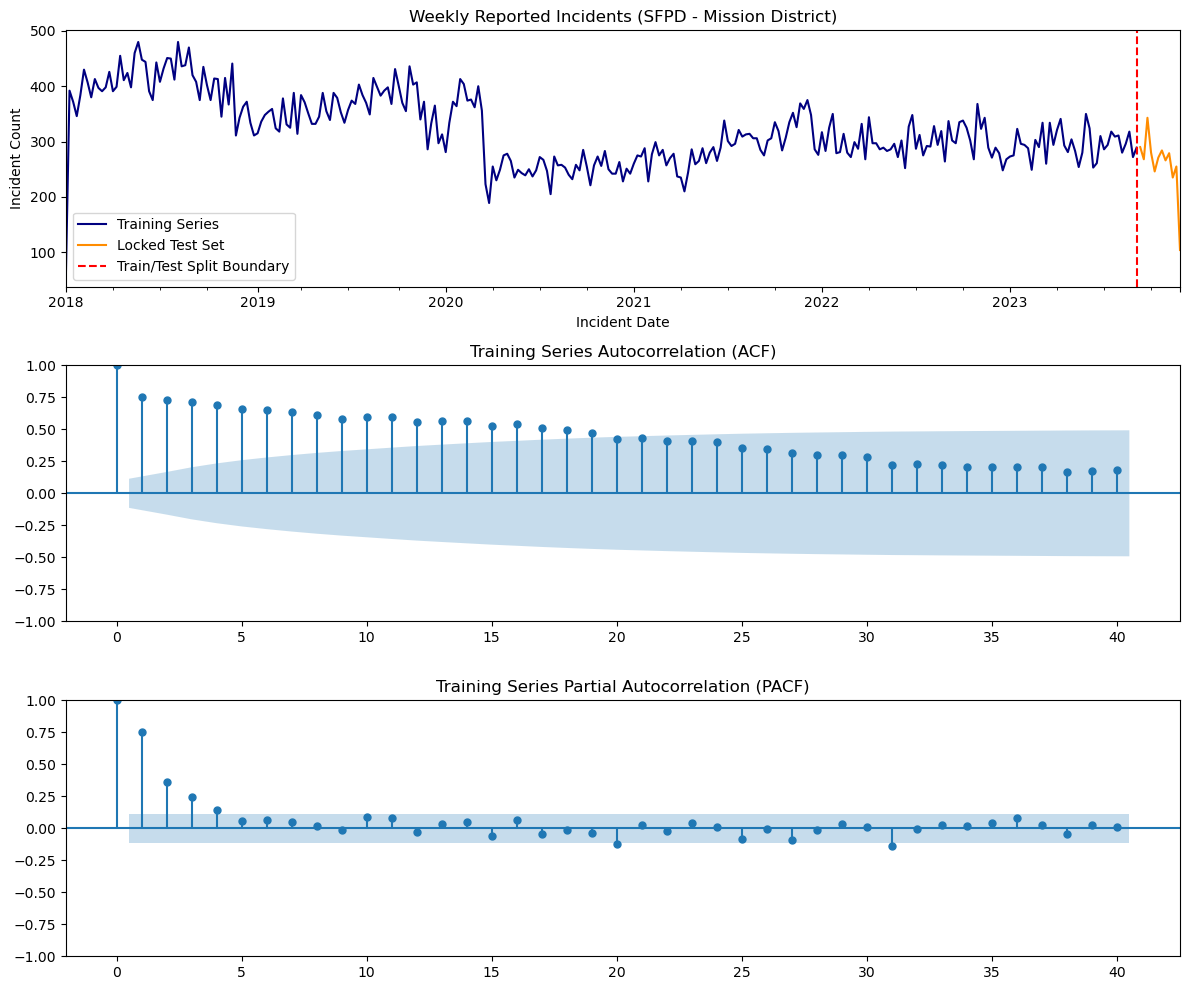


Naive Baseline: MAE = 38.08, RMSE = 60.94
AR(4):         MAE = 45.28, RMSE = 66.78

Selected ARIMA Order: (1, 1, 1) (Training AIC: 2970.36)
ARIMA(1, 1, 1):     MAE = 40.10, RMSE = 62.23

--- ARIMA Residual Ljung-Box Test ---
      lb_stat  lb_pvalue
10  20.347821   0.026129
20  30.208149   0.066550

--- Final Model Evaluation Table ---
         Model Order/Lags   Train AIC       MAE      RMSE  Ljung-Box p(10)
Naive Baseline          -         NaN 38.083333 60.939177              NaN
ARIMA(1, 1, 1)  (1, 1, 1) 2970.357213 40.095910 62.231103         0.026129
         AR(4)        p=4 2858.288476 45.284710 66.777328              NaN


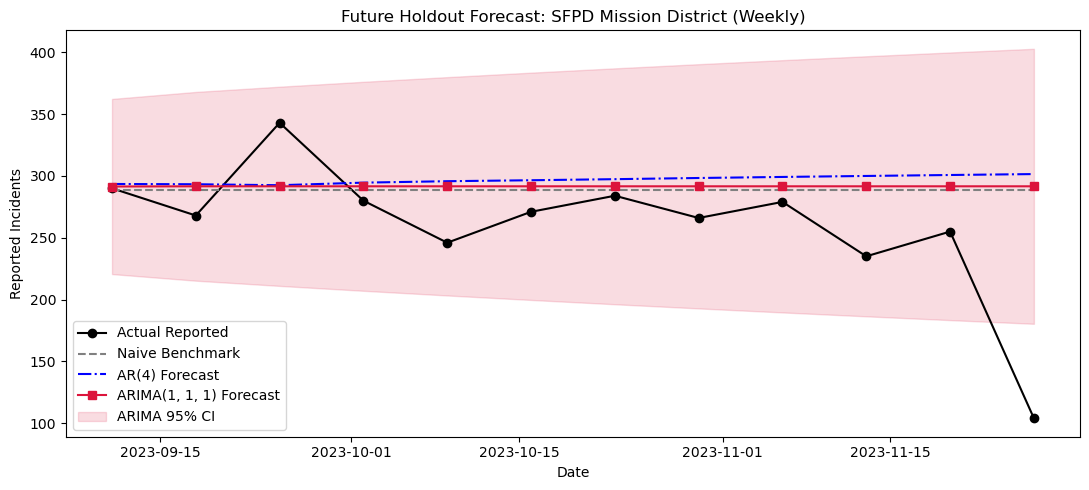


Pipeline execution complete. All artifacts saved to /lab06_outputs.


In [7]:
import os
import glob
import json
import platform
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox




# ==========================================
# 0. CONFIGURATION & DIRECT DATA PATH
# ==========================================
SEED = 42
np.random.seed(SEED)

OUT = Path("lab06_outputs")
OUT.mkdir(exist_ok=True)

CONFIG = {
    "dataset": "SFPD Incident Reports: 2018 to Present",
    "date_col": "Incident Date",
    "location_col": "Police District",
    "location_value": "Mission",   # Selected SFPD District
    "frequency": "W-MON",          # Weekly aggregation on Mondays
    "test_periods": 12,            # 12-week locked chronological holdout
    "seed": SEED
}
print("Experiment Configuration:", CONFIG)

# ==========================================
# 1. DATA LOADING & PREPROCESSING
# ==========================================
# Set the exact path where your downloaded CSV is saved
DATA_PATH = R"C:/Users/ADMIN/Downloads/archive (20)/Police_Department_Incident_Reports__2018_to_Present.csv"

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f"File not found at: {DATA_PATH}. Please check the file name and path.")

use_cols = [CONFIG["date_col"], CONFIG["location_col"], "Incident Category"]

df = pd.read_csv(
    DATA_PATH,
    usecols=use_cols,
    low_memory=False
)

# Parse occurrence dates and drop missing records
df[CONFIG["date_col"]] = pd.to_datetime(df[CONFIG["date_col"]], errors="coerce")
df = df.dropna(subset=[CONFIG["date_col"], CONFIG["location_col"]]).copy()

# Filter multi-year window to ensure stable reporting periods
df = df[(df[CONFIG["date_col"]] >= "2018-01-01") & (df[CONFIG["date_col"]] <= "2023-12-31")]

# ==========================================
# 2. TIME SERIES AGGREGATION (Location-Specific)
# ==========================================
# Filter to selected police district (case-insensitive)
loc_df = df[df[CONFIG["location_col"]].astype(str).str.strip().str.upper() == CONFIG["location_value"].upper()].copy()
assert len(loc_df) > 0, f"No records found for District: {CONFIG['location_value']}"

# Aggregate to regular weekly complaint counts
y = (loc_df.set_index(CONFIG["date_col"])
     .resample(CONFIG["frequency"])
     .size()
     .rename("incidents")
     .asfreq(CONFIG["frequency"], fill_value=0))

# Acceptance integrity checks
assert y.index.is_monotonic_increasing
assert y.index.is_unique
assert y.isna().sum() == 0

print("\n--- Summary Statistics of Target Series ---")
print(y.describe())

# ==========================================
# 3. LEAKAGE-SAFE CHRONOLOGICAL SPLIT
# ==========================================
H = CONFIG["test_periods"]
assert len(y) > 3 * H, "Series is too short for the chosen holdout period."

# Chronological split: oldest data for train, newest H weeks for test
train, test = y.iloc[:-H], y.iloc[-H:]

assert train.index.max() < test.index.min()
assert len(test) == H
print(f"\nTraining set: {train.index.min().date()} to {train.index.max().date()} ({len(train)} weeks)")
print(f"Locked Test set: {test.index.min().date()} to {test.index.max().date()} ({len(test)} weeks)")

def compute_metrics(y_true, y_pred):
    return {
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "RMSE": float(mean_squared_error(y_true, y_pred) ** 0.5)
    }

# ==========================================
# 4. EXPLORATORY DATA ANALYSIS & STATIONARITY (Training Only)
# ==========================================
fig, ax = plt.subplots(3, 1, figsize=(12, 10))

# 4.1 Incident count plot with train/test boundary
train.plot(ax=ax[0], label="Training Series", color="navy")
test.plot(ax=ax[0], label="Locked Test Set", color="darkorange")
ax[0].axvline(train.index.max(), color="red", linestyle="--", label="Train/Test Split Boundary")
ax[0].set_title(f"Weekly Reported Incidents (SFPD - {CONFIG['location_value']} District)")
ax[0].set_ylabel("Incident Count")
ax[0].legend()

# 4.2 Augmented Dickey-Fuller Test on training series
adf_stat, adf_p, _, _, crit_vals, _ = adfuller(train)
print(f"\n--- Stationarity Test (Training Only) ---")
print(f"ADF Statistic: {adf_stat:.4f} | p-value: {adf_p:.4e}")

# 4.3 ACF & PACF on training series
max_lags = min(40, len(train) // 4)
plot_acf(train, lags=max_lags, ax=ax[1], title="Training Series Autocorrelation (ACF)")
plot_pacf(train, lags=max_lags, ax=ax[2], method="ywm", title="Training Series Partial Autocorrelation (PACF)")
plt.tight_layout()
plt.savefig(OUT / "eda_and_diagnostics.png", dpi=300)
plt.show()

# ==========================================
# 5. MODEL 1: NAIVE BASELINE (Last Value)
# ==========================================
# Reference benchmark using the last observed training point
naive_pred = np.repeat(train.iloc[-1], len(test))
naive_metrics = compute_metrics(test, naive_pred)
print(f"\nNaive Baseline: MAE = {naive_metrics['MAE']:.2f}, RMSE = {naive_metrics['RMSE']:.2f}")

# ==========================================
# 6. MODEL 2: AUTOREGRESSIVE (AR) MODEL
# ==========================================
# AR lag order selected based on PACF structure
AR_LAGS = 4
ar_fitted = AutoReg(train, lags=AR_LAGS, trend="c", old_names=False).fit()
ar_pred = ar_fitted.predict(start=len(train), end=len(train) + len(test) - 1, dynamic=False)
ar_metrics = compute_metrics(test, ar_pred)
print(f"AR({AR_LAGS}):         MAE = {ar_metrics['MAE']:.2f}, RMSE = {ar_metrics['RMSE']:.2f}")

# ==========================================
# 7. MODEL 3: ARIMA MODEL SELECTION & FORECAST
# ==========================================
# Candidate orders evaluated strictly on training data
candidates = [(1, 0, 0), (2, 0, 0), (1, 1, 1), (2, 1, 1), (4, 1, 1)]
candidate_results = []

for order in candidates:
    try:
        m = ARIMA(train, order=order).fit()
        candidate_results.append({
            "order": order,
            "AIC": m.aic,
            "BIC": m.bic,
            "fitted_model": m
        })
    except Exception as e:
        print(f"Candidate {order} failed: {e}")

# Select best candidate by training AIC
candidate_results.sort(key=lambda x: x["AIC"])
best_arima_info = candidate_results[0]
best_order = best_arima_info["order"]
arima_fitted = best_arima_info["fitted_model"]

print(f"\nSelected ARIMA Order: {best_order} (Training AIC: {best_arima_info['AIC']:.2f})")

# Forecast locked test horizon
arima_forecast_obj = arima_fitted.get_forecast(steps=len(test))
arima_pred = arima_forecast_obj.predicted_mean
arima_conf_int = arima_forecast_obj.conf_int(alpha=0.05)
arima_metrics = compute_metrics(test, arima_pred)
print(f"ARIMA{best_order}:     MAE = {arima_metrics['MAE']:.2f}, RMSE = {arima_metrics['RMSE']:.2f}")

# ==========================================
# 8. RESIDUAL DIAGNOSTICS
# ==========================================
resid = arima_fitted.resid.dropna()
lb_test = acorr_ljungbox(resid, lags=[10, 20], return_df=True)
print("\n--- ARIMA Residual Ljung-Box Test ---")
print(lb_test)

# ==========================================
# 9. COMPARISON TABLE & ARTIFACT EXPORT
# ==========================================
results_df = pd.DataFrame([
    {"Model": "Naive Baseline", "Order/Lags": "-", "Train AIC": np.nan, **naive_metrics, "Ljung-Box p(10)": np.nan},
    {"Model": f"AR({AR_LAGS})", "Order/Lags": f"p={AR_LAGS}", "Train AIC": ar_fitted.aic, **ar_metrics, "Ljung-Box p(10)": np.nan},
    {"Model": f"ARIMA{best_order}", "Order/Lags": str(best_order), "Train AIC": best_arima_info["AIC"], **arima_metrics, "Ljung-Box p(10)": lb_test.loc[10, "lb_pvalue"]}
]).sort_values("MAE")

print("\n--- Final Model Evaluation Table ---")
print(results_df.to_string(index=False))

# Export results
results_df.to_csv(OUT / "model_comparison.csv", index=False)

# Export predictions
pred_df = pd.DataFrame({
    "actual": test,
    "naive": naive_pred,
    "AR": np.asarray(ar_pred),
    "ARIMA": np.asarray(arima_pred),
    "ARIMA_lower_95": arima_conf_int.iloc[:, 0].values,
    "ARIMA_upper_95": arima_conf_int.iloc[:, 1].values
}, index=test.index)
pred_df.to_csv(OUT / "test_predictions.csv")

# Export manifest
manifest = {
    **CONFIG,
    "n_total_periods": int(len(y)),
    "n_train": int(len(train)),
    "n_test": int(len(test)),
    "selected_arima_order": list(best_order),
    "python_version": sys.version,
    "platform": platform.platform()
}
(OUT / "manifest.json").write_text(json.dumps(manifest, indent=2, default=str))

# Plot forecast comparison
plt.figure(figsize=(11, 5))
plt.plot(test.index, test, marker="o", label="Actual Reported", color="black", linewidth=1.5)
plt.plot(test.index, naive_pred, linestyle="--", label="Naive Benchmark", color="gray")
plt.plot(test.index, ar_pred, linestyle="-.", label=f"AR({AR_LAGS}) Forecast", color="blue")
plt.plot(test.index, arima_pred, marker="s", label=f"ARIMA{best_order} Forecast", color="crimson")
plt.fill_between(test.index, arima_conf_int.iloc[:, 0], arima_conf_int.iloc[:, 1], color="crimson", alpha=0.15, label="ARIMA 95% CI")
plt.title(f"Future Holdout Forecast: SFPD {CONFIG['location_value']} District (Weekly)")
plt.xlabel("Date")
plt.ylabel("Reported Incidents")
plt.legend()
plt.tight_layout()
plt.savefig(OUT / "holdout_forecast_plot.png", dpi=300)
plt.show()

# Verification assertions
assert (OUT / "model_comparison.csv").exists()
assert (OUT / "test_predictions.csv").exists()
assert (OUT / "manifest.json").exists()
print("\nPipeline execution complete. All artifacts saved to /lab06_outputs.")